In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import decimate
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import os
# Seed para reprodutibilidade
rseed = 42
np.random.seed(rseed)
torch.manual_seed(rseed)
np.set_printoptions(precision=3)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [16]:
# ==========================================
# 1. CARREGAMENTO DOS DADOS (Baseado no Polinomial)
# ==========================================
BASE = "https://raw.githubusercontent.com/FelipeEduardoMarcondes/SYSTEM-IDENTIFICATION-AERO/main/experimentos/"

F_MIX_FILES = [
    "aprbs-1_0827_17-19.csv", "aprbs-2_0827_17-25.csv", "aprbs-3_0827_17-28.csv", "aprbs-4_0827_17-31.csv",
    "multi-seno-1_0827_17-34.csv", "multi-seno-2_0827_17-37.csv", "multi-seno-3_0827_17-40.csv", "multi-seno-4_0827_17-43.csv",
    "swept-sine-1_0827_17-58.csv", "swept-sine-4_0827_18-00.csv",
    "seq-degraus-1_0827_17-46.csv", "seq-degraus-2_0827_17-49.csv", "seq-degraus-3_0827_17-52.csv", "seq-degraus-4_0827_17-55.csv",
    "RODADA-3/chirp-1_0807_16-34.csv", "RODADA-3/chirp-2_0807_17-07.csv", "RODADA-3/chirp-2_0807_17-09.csv"
]

TEST_FILES_BY_TYPE = {
    "APRBS":     "RODADA-4/aprbs-2_0819_18-51.csv",
    "MultiSeno": "RODADA-2/multi-seno-1_0804_19-06.csv",
    "SweptSine": "RODADA-4/swept-sine-1_0819_19-02.csv",
    "Degraus":   "RODADA-2/seq-degraus-2_0804_19-38.csv",
    "Chirp":     "RODADA-2/chirp-1_0804_19-19.csv",
}

DECIMACAO = 2
START_IDX = 200
END_IDX   = -200

scaler_u = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))
scaler_u.fit(np.array([[-100], [100]]))
scaler_y.fit(np.array([[-180], [180]]))

def carregar_experimento(url, decimacao=DECIMACAO, start_idx=START_IDX, end_idx=END_IDX):
    df = pd.read_csv(url)
    if 'referencia' in df.columns:
        df = df[df['referencia'] > 0]
    u_full = df['u_pct'].values.astype(np.float64) if 'u_pct' in df.columns else df['motor_percent'].values.astype(np.float64)
    y_full = df['angulo_deg'].values.astype(np.float64)
    
    if decimacao > 1:
        y_raw = decimate(y_full, decimacao, ftype='iir', zero_phase=True)
        u_raw = u_full[::decimacao]
    else:
        u_raw, y_raw = u_full, y_full
        
    dt = 0.010 * decimacao
    t_raw = np.arange(len(y_raw)) * dt
    min_l = min(len(y_raw), len(u_raw))
    t_raw, u_raw, y_raw = t_raw[:min_l], u_raw[:min_l], y_raw[:min_l]
    
    if start_idx is not None and end_idx is not None:
        t_raw = t_raw[start_idx:end_idx]
        u_raw = u_raw[start_idx:end_idx]
        y_raw = y_raw[start_idx:end_idx]
        
    t_raw = t_raw - t_raw[0]
    return t_raw, u_raw, y_raw

def processar_dataset(t_raw, u_raw, y_raw):
    u_norm = scaler_u.transform(u_raw.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()
    return t_raw, u_norm, y_norm, u_raw, y_raw

def carregar_lista(file_list):
    datasets = []
    for f in file_list:
        t, u_raw, y_raw = carregar_experimento(BASE + f)
        t, u_norm, y_norm, _, _ = processar_dataset(t, u_raw, y_raw)
        datasets.append({
            'name': os.path.basename(f),
            't': t, 'u_norm': u_norm, 'y_norm': y_norm,
            'u_raw': u_raw, 'y_raw': y_raw
        })
    return datasets

In [17]:
print("Carregando dataset misto (F_Mix) de treinamento...")
train_datasets = carregar_lista(F_MIX_FILES)

print("\nCarregando conjuntos de Teste (Cross-Session)...")
test_por_tipo = {tipo: carregar_lista([arquivo]) for tipo, arquivo in TEST_FILES_BY_TYPE.items()}

Carregando dataset misto (F_Mix) de treinamento...

Carregando conjuntos de Teste (Cross-Session)...


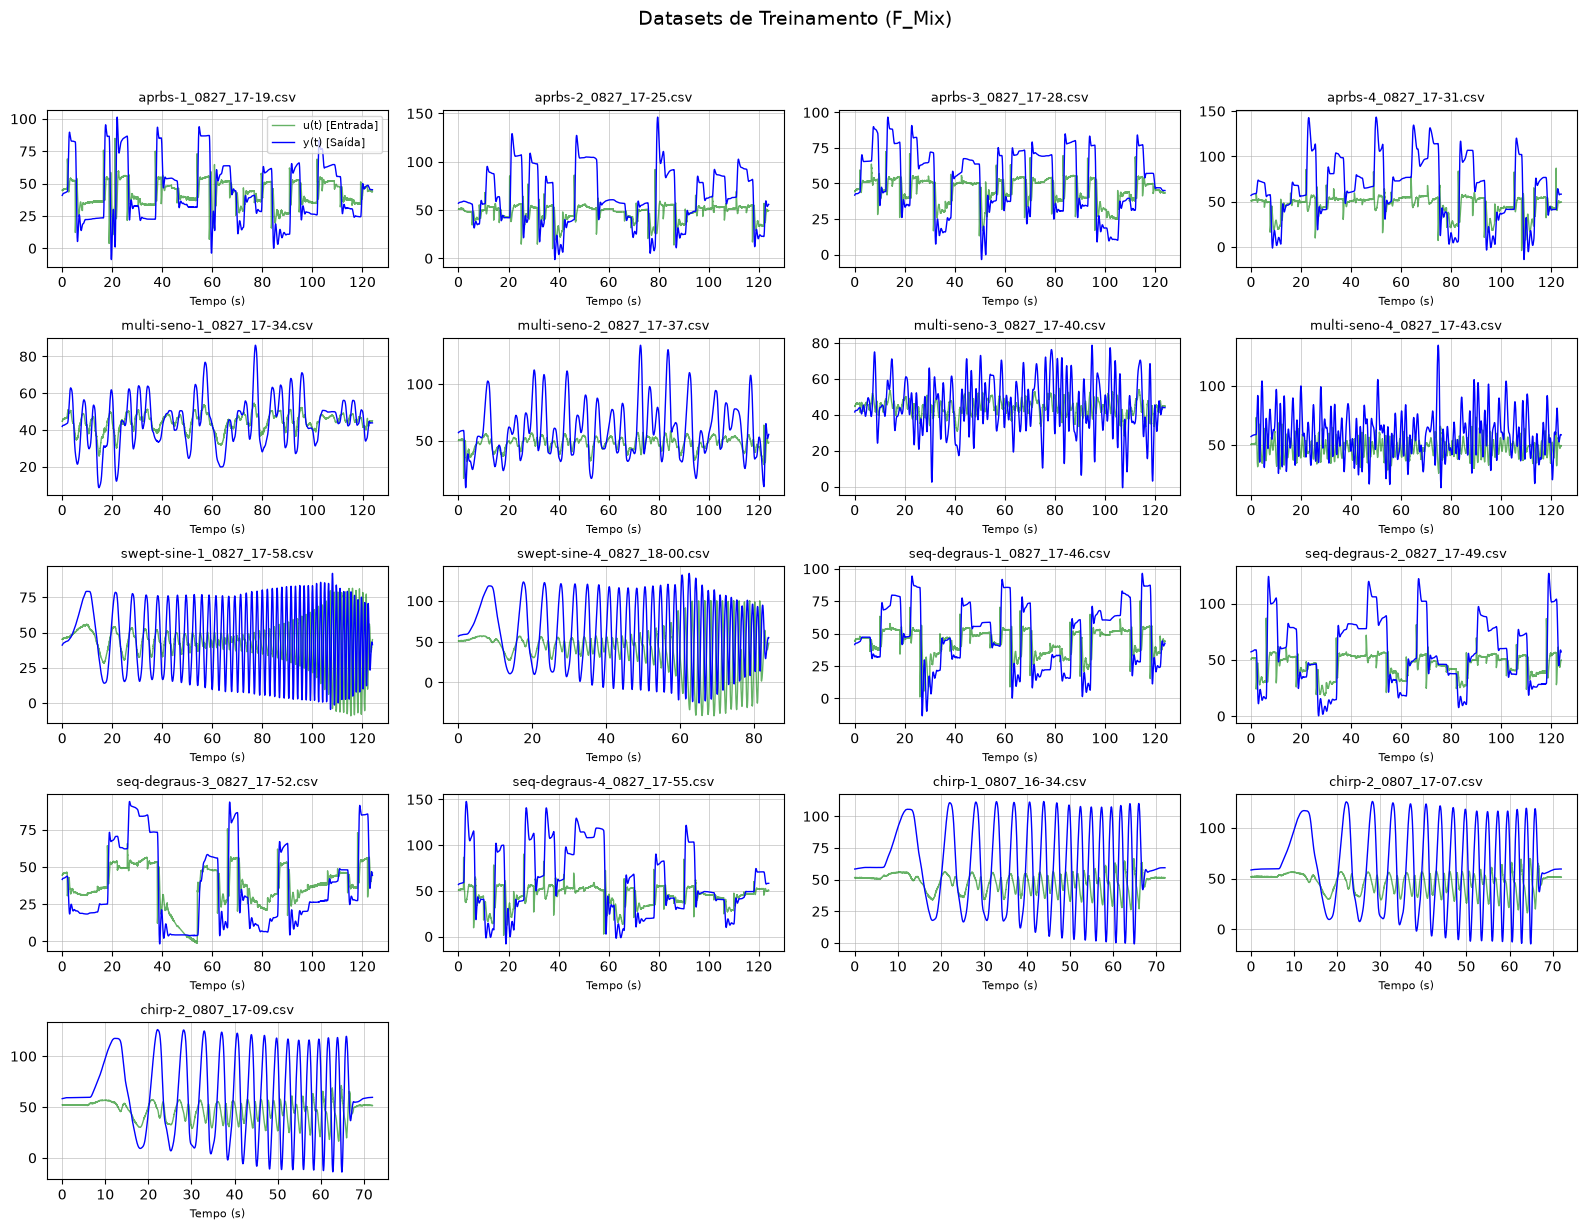

In [18]:
def plot_datasets_grid(datasets_list, title):
    n = len(datasets_list)
    cols = min(4, n)
    rows = -(-n // cols)
    fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 2.5*rows))
    fig.suptitle(title, fontsize=14)
    
    if n == 1:
        axs = np.array([[axs]])
    elif rows == 1:
        axs = np.array([axs])
        
    for i, ds in enumerate(datasets_list):
        ax = axs[i // cols, i % cols]
        ax.plot(ds['t'], ds['u_raw'], 'g-', lw=1, alpha=0.6, label='u(t) [Entrada]')
        ax.plot(ds['t'], ds['y_raw'], 'b-', lw=1, label='y(t) [Saída]')
        ax.set_title(ds['name'], fontsize=9)
        ax.set_xlabel('Tempo (s)', fontsize=8)
        if i == 0:
            ax.legend(fontsize=8)
        ax.grid(True, lw=0.4)
        
    for i in range(n, rows * cols):
        axs[i // cols, i % cols].axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()
    
plot_datasets_grid(train_datasets, "Datasets de Treinamento (F_Mix)")

In [19]:
# ==========================================
# 2. PREPARAÇÃO DOS DADOS PARA REDE NEURAL BPTT
# ==========================================
ny = 60
nu = 60
H = 10 # Horizonte Multi-Step

def make_bptt_windows(y, u, ny, nu, H):
    p_start = max(ny, nu)
    p_end = len(y) - H + 1
    Y_past_list, Y_target_list, U_seq_list = [], [], []
    for p in range(p_start, p_end):
        # Ordem cronológica
        Y_past_list.append(y[p - ny : p])
        Y_target_list.append(y[p : p + H])
        U_seq_list.append(u[p - nu : p + H - 1])
    return np.array(Y_past_list), np.array(Y_target_list), np.array(U_seq_list)

Y_past_all, Y_target_all, U_seq_all = [], [], []
for ds in train_datasets:
    yp, yt, us = make_bptt_windows(ds['y_norm'], ds['u_norm'], ny, nu, H)
    if len(yp) > 0:
        Y_past_all.append(yp)
        Y_target_all.append(yt)
        U_seq_all.append(us)

Y_past_t = torch.tensor(np.concatenate(Y_past_all, axis=0), dtype=torch.float32).to(device)
Y_target_t = torch.tensor(np.concatenate(Y_target_all, axis=0), dtype=torch.float32).to(device)
U_seq_t = torch.tensor(np.concatenate(U_seq_all, axis=0), dtype=torch.float32).to(device)

dataset = TensorDataset(Y_past_t, U_seq_t, Y_target_t)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
print(f"Total de janelas de treinamento: {len(dataset)}")

Total de janelas de treinamento: 94435


In [20]:
# ==========================================
# 3. ARQUITETURA DA REDE NARX
# ==========================================
class NARXModel(nn.Module):
    def __init__(self, ny, nu, hidden_dim1=128, hidden_dim2=64, dropout=0.1):
        super().__init__()
        self.ny = ny
        self.nu = nu
        self.linear_bypass = nn.Linear(ny + nu, 1)
        self.net = nn.Sequential(
            nn.Linear(ny + nu, hidden_dim1),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, 1)
        )
    
    def forward(self, x):
        return self.linear_bypass(x) + self.net(x)
        
    def multi_step_forward(self, y_past, u_seq, H):
        # y_past: (B, ny) in chronological order
        # u_seq: (B, nu + H - 1) in chronological order
        y_preds = []
        y_buffer = y_past.clone()
        for h in range(H):
            y_in = y_buffer[:, -self.ny:]
            u_in = u_seq[:, h : h + self.nu]
            x = torch.cat([y_in, u_in], dim=1)
            pred = self.forward(x) # (B, 1)
            y_preds.append(pred)
            y_buffer = torch.cat([y_buffer, pred], dim=1)
        return torch.cat(y_preds, dim=1) # (B, H)\

In [ ]:
# ==========================================
# 4. TREINAMENTO
# ==========================================
model = NARXModel(ny, nu, 256, 128).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

epochs = 100
best_val_loss = float('inf')
patience_counter = 0
patience_limit = 50 # reduzido para acelerar o early stopping

# Utilizar o primeiro arquivo do grupo MultiSeno de teste para a validação no loop
val_ds = test_por_tipo['MultiSeno'][0]
H_val = len(val_ds['y_norm']) - max(ny, nu)
yp_val, yt_val, us_val = make_bptt_windows(val_ds['y_norm'], val_ds['u_norm'], ny, nu, H_val)

Yp_val_t = torch.tensor(yp_val[0:1], dtype=torch.float32).to(device) 
Us_val_t = torch.tensor(us_val[0:1], dtype=torch.float32).to(device)
Yt_val_t = torch.tensor(yt_val[0:1], dtype=torch.float32).to(device)

print("Iniciando treinamento da rede...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for y_past, u_seq, targets in dataloader:
        optimizer.zero_grad()
        outputs = model.multi_step_forward(y_past, u_seq, H)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    epoch_loss /= len(dataloader)
    
    # Validação via Free-Run Completo no dataset de validacao
    model.eval()
    if (epoch + 1) % 5 == 0 or epoch == 0:
        with torch.no_grad():
            preds_val = model.multi_step_forward(Yp_val_t, Us_val_t, H_val)
            val_loss = criterion(preds_val, Yt_val_t).item()
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_narx_v5.pth')
            patience_counter = 0
            best_ep = epoch + 1
        else:
            patience_counter += 5
            
        print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss (H={H}): {epoch_loss:.5f} | Val Loss (Free-Run): {val_loss:.5f} | Best Loss: {best_val_loss:.5f}')
        
        if patience_counter >= patience_limit:
            print(f"Early stopping na epoch {epoch+1}. Melhor epoch foi {best_ep}")
            break

Iniciando treinamento da rede...
Epoch   1/100 | Train Loss (H=10): 0.00310 | Val Loss (Free-Run): 2983217.75000 | Best Loss: 2983217.75000
Epoch   5/100 | Train Loss (H=10): 0.00025 | Val Loss (Free-Run): 100.00974 | Best Loss: 100.00974
Epoch  10/100 | Train Loss (H=10): 0.00017 | Val Loss (Free-Run): 0.03472 | Best Loss: 0.03472
Epoch  15/100 | Train Loss (H=10): 0.00012 | Val Loss (Free-Run): 0.01875 | Best Loss: 0.01875
Epoch  20/100 | Train Loss (H=10): 0.00010 | Val Loss (Free-Run): 0.08588 | Best Loss: 0.01875


In [ ]:
# ==========================================
# 5. AVALIAÇÃO COM GRID E MÉTRICAS (Estilo Polinomial)
# ==========================================
print("\n--- AVALIAÇÃO FREE-RUN NOS TESTES ---")
model.load_state_dict(torch.load('best_narx_v5.pth'))
model.eval()

def avalia_free_run_ann(model, datasets, ny, nu):
    resultados = []
    p = max(ny, nu)
    for ds in datasets:
        y_norm = ds['y_norm']
        u_norm = ds['u_norm']
        
        H_test = len(y_norm) - p
        yp_test, yt_test, us_test = make_bptt_windows(y_norm, u_norm, ny, nu, H_test)
        
        if len(yp_test) == 0:
            continue
            
        Yp_t = torch.tensor(yp_test[0:1], dtype=torch.float32).to(device)
        Us_t = torch.tensor(us_test[0:1], dtype=torch.float32).to(device)
        
        with torch.no_grad():
            y_pred_norm = model.multi_step_forward(Yp_t, Us_t, H_test).cpu().numpy().flatten()
            
        # O modelo cospe a sequencia do futuro a partir de p
        y_real_valid = ds['y_raw'][p:]
        t_valid = ds['t'][p:]
        
        y_pred = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
        
        rmse = float(np.sqrt(np.mean((y_pred - y_real_valid) ** 2)))
        r2 = float(r2_score(y_real_valid, y_pred))
        fit = float((1 - np.linalg.norm(y_pred - y_real_valid) / (np.linalg.norm(y_real_valid - np.mean(y_real_valid)) + 1e-12)) * 100)
        
        resultados.append({
            'name': ds['name'], 'rmse': rmse, 'r2': r2, 'fit': fit,
            'y_real': y_real_valid, 'y_pred': y_pred, 't': t_valid
        })
    return resultados

todos_resultados = []
for tipo, dsl in test_por_tipo.items():
    res = avalia_free_run_ann(model, dsl, ny, nu)
    todos_resultados.extend(res)
    rmse_m = np.mean([r['rmse'] for r in res])
    r2_m = np.mean([r['r2'] for r in res])
    fit_m = np.mean([r['fit'] for r in res])
    print(f"[{tipo:<10}] RMSE: {rmse_m:5.2f} deg  |  R2: {r2_m:6.3f}  |  FIT: {fit_m:5.1f}%")
    
# Plotar a grade inteira!
n = len(todos_resultados)
cols = min(3, n)
rows = -(-n // cols)
fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 3.5 * rows))
fig.suptitle('Desempenho do Modelo ANN NARX v5 (F_Mix) nos Testes Ocultos', fontsize=14)

if n == 1:
    axs = np.array([[axs]])
elif rows == 1:
    axs = np.array([axs])
else:
    axs = np.array(axs).reshape(rows, cols)

for i, r in enumerate(todos_resultados):
    ax = axs[i // cols, i % cols]
    ax.plot(r['t'], r['y_real'], 'k',   lw=1.2, label='Real')
    ax.plot(r['t'], r['y_pred'], 'r--', lw=1.0, label='Pred (Free-Run)')
    ax.set_title(f"{r['name']}\nRMSE={r['rmse']:.2f}deg FIT={r['fit']:.1f}%", fontsize=9)
    ax.set_xlabel('Tempo (s)', fontsize=8)
    ax.set_ylabel('Angulo (deg)', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4)

for i in range(n, rows * cols):
    axs[i // cols, i % cols].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()